# Bonus

🎯 84 feature’dan oluşan tam `ML_Houses_dataset.csv` dataset’iyle [buradan ulaşarak](https://d32aokrjazspmn.cloudfront.net/materials/ML_Houses_dataset.csv) serbestçe çalışabilirsiniz!

- Feature’ları inceleyin
- Uygun şekilde preprocess edin ve encode edin
- Feature engineering için beyin fırtınası yapın
- Bunları modelinize ekleyin
- Feature selection uygulayın

👇 Dosyayı yerel olarak `data` klasörüne kaydedin ve buradan içe aktarın.

In [2]:
# SENİN KODUN BURAYA
import pandas as pd

df = pd.read_csv("data/ML_Houses_dataset.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("Veri seti boyutu:", df.shape)
print("Tekrarlanan satır sayısı:", df.duplicated().sum())
print("Hedef değişken var mı?:", "SalePrice" in df.columns)

print("\nVeri tiplerinin dağılımı:")
print(df.dtypes.value_counts())

print("\nEn fazla eksik değere sahip 20 sütun:")
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
})

display(
    missing_summary
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
    .head(20)
)

Veri seti boyutu: (1760, 85)
Tekrarlanan satır sayısı: 300
Hedef değişken var mı?: True

Veri tiplerinin dağılımı:
object     45
int64      35
float64     5
Name: count, dtype: int64

En fazla eksik değere sahip 20 sütun:


,missing_count,missing_percent
WallMat,1755,99.715909
PoolQC,1751,99.488636
MiscFeature,1694,96.250000
Alley,1648,93.636364
Fence,1418,80.568182
MasVnrType,1062,60.340909
FireplaceQu,827,46.988636
LotFrontage,309,17.556818
GarageType,93,5.284091
GarageYrBlt,93,5.284091


In [4]:
# Yinelenen satırları kaldır
row_count_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

row_count_after = len(df)

print("Önceki satır sayısı:", row_count_before)
print("Sonraki satır sayısı:", row_count_after)
print("Silinen yinelenen satır:", row_count_before - row_count_after)
print("Kalan yinelenen satır:", df.duplicated().sum())

Önceki satır sayısı: 1760
Sonraki satır sayısı: 1460
Silinen yinelenen satır: 300
Kalan yinelenen satır: 0


In [5]:
# Model açısından anlam taşımayan kimlik sütununu kaldır
df = df.drop(columns=["Id"], errors="ignore")

# NaN = ilgili özellik evde bulunmuyor anlamındaki kategorik sütunlar
absence_categorical_cols = [
    "Alley",
    "MasVnrType",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature"
]

# Yalnızca DataFrame'de bulunan sütunları seç
absence_categorical_cols = [
    col for col in absence_categorical_cols
    if col in df.columns
]

df[absence_categorical_cols] = (
    df[absence_categorical_cols].fillna("None")
)

# NaN = ilgili alan bulunmuyor, dolayısıyla sayısal değeri 0
absence_numeric_cols = [
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "GarageYrBlt",
    "GarageCars",
    "GarageArea"
]

absence_numeric_cols = [
    col for col in absence_numeric_cols
    if col in df.columns
]

df[absence_numeric_cols] = (
    df[absence_numeric_cols].fillna(0)
)

# Kalan eksik değerleri kontrol et
remaining_missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

remaining_missing = (
    remaining_missing
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
)

print("Yeni veri seti boyutu:", df.shape)
print("Eksik değeri kalan sütun sayısı:", len(remaining_missing))

display(remaining_missing)

Yeni veri seti boyutu: (1460, 84)
Eksik değeri kalan sütun sayısı: 5


,missing_count,missing_percent
WallMat,1455,99.657534
LotFrontage,259,17.739726
Pesos,10,0.684932
RoofSurface,9,0.616438
Electrical,1,0.068493


In [8]:
remaining_cols = [
    "WallMat",
    "LotFrontage",
    "Pesos",
    "RoofSurface",
    "Electrical"
]

for col in remaining_cols:
    print(f"\n--- {col} ---")
    print("Veri tipi:", df[col].dtype)
    print("Benzersiz değer sayısı:", df[col].nunique(dropna=True))
    print("İlk değerler:")
    print(df[col].dropna().head(10).tolist())
# Neredeyse tamamen boş olduğu için kaldır
df = df.drop(columns=["WallMat"])

# Cephe uzunluğunu mahalle medyanına göre doldur
df["LotFrontage"] = df["LotFrontage"].fillna(
    df.groupby("Neighborhood")["LotFrontage"].transform("median")
)

# Her ihtimale karşı kalanları genel medyanla doldur
df["LotFrontage"] = df["LotFrontage"].fillna(
    df["LotFrontage"].median()
)

# Electrical sütunundaki tek eksik değeri mod ile doldur
df["Electrical"] = df["Electrical"].fillna(
    df["Electrical"].mode()[0]
)

print(df[["LotFrontage", "Electrical"]].isna().sum())


--- WallMat ---
Veri tipi: object
Benzersiz değer sayısı: 2
İlk değerler:
['Concrete', 'Wood', 'Wood', 'Concrete', 'Concrete']

--- LotFrontage ---
Veri tipi: float64
Benzersiz değer sayısı: 110
İlk değerler:
[65.0, 80.0, 68.0, 60.0, 84.0, 85.0, 75.0, 51.0, 50.0, 70.0]

--- Pesos ---
Veri tipi: float64
Benzersiz değer sayısı: 660
İlk değerler:
[4170000.0, 3630000.0, 4470000.0, 2800000.0, 5000000.0, 2860000.0, 6140000.0, 4000000.0, 2598000.0, 2360000.0]

--- RoofSurface ---
Veri tipi: float64
Benzersiz değer sayısı: 1254
İlk değerler:
[1995.0, 874.0, 1593.0, 2566.0, 3130.0, 1056.0, 4141.0, 1424.0, 2243.0, 3216.0]

--- Electrical ---
Veri tipi: object
Benzersiz değer sayısı: 5
İlk değerler:
['SBrkr', 'SBrkr', 'SBrkr', 'SBrkr', 'SBrkr', 'SBrkr', 'SBrkr', 'SBrkr', 'FuseF', 'SBrkr']
LotFrontage    0
Electrical     0
dtype: int64


ℹ️ Dataset’in açıklamasına mutlaka [buradan](https://drive.google.com/file/d/1qLxeQXufW_-KHOckpUweLPhitzjnP7H3/view?usp=sharing) referans verin.

In [10]:
# Hedef değişkenden türetildiği için kaldır
df = df.drop(columns=["Pesos"], errors="ignore")

# RoofSurface eksiklerini medyanla doldur
df["RoofSurface"] = df["RoofSurface"].fillna(
    df["RoofSurface"].median()
)

# Son kontrol
print("Toplam eksik değer:", df.isna().sum().sum())

missing_cols = df.isna().sum()
print(missing_cols[missing_cols > 0])

Toplam eksik değer: 0
Series([], dtype: int64)


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
Çarpıklık değeri: 1.8828757597682129


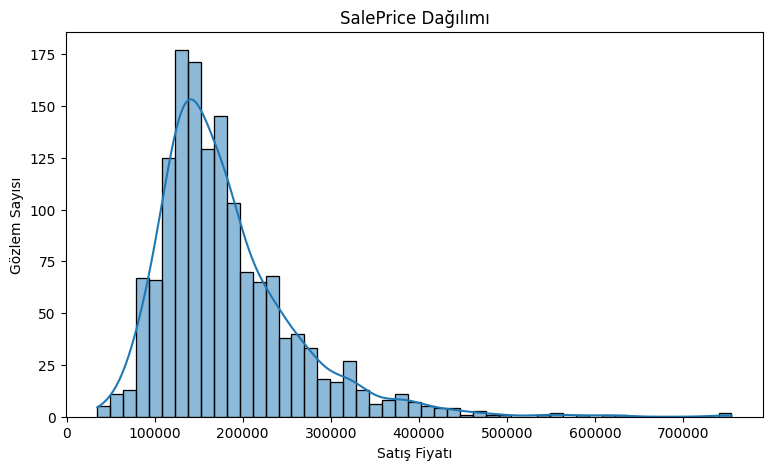

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df["SalePrice"].describe())
print("Çarpıklık değeri:", df["SalePrice"].skew())

plt.figure(figsize=(9, 5))
sns.histplot(df["SalePrice"], kde=True)

plt.title("SalePrice Dağılımı")
plt.xlabel("Satış Fiyatı")
plt.ylabel("Gözlem Sayısı")
plt.show()

In [12]:
import numpy as np

# Toplam kullanılabilir alan
df["TotalSF"] = (
    df["TotalBsmtSF"]
    + df["1stFlrSF"]
    + df["2ndFlrSF"]
)

# Toplam banyo sayısı
df["TotalBathrooms"] = (
    df["FullBath"]
    + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["BsmtHalfBath"]
)

# Toplam dış alan
df["TotalOutdoorSF"] = (
    df["WoodDeckSF"]
    + df["OpenPorchSF"]
    + df["EnclosedPorch"]
    + df["3SsnPorch"]
    + df["ScreenPorch"]
)

# Satış tarihindeki ev ve tadilat yaşı
df["HouseAge"] = (df["YrSold"] - df["YearBuilt"]).clip(lower=0)
df["RemodAge"] = (df["YrSold"] - df["YearRemodAdd"]).clip(lower=0)

# Belirli özelliklerin bulunup bulunmadığı
df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)
df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
df["HasPool"] = (df["PoolArea"] > 0).astype(int)

# Modelleme sırasında kullanılacak logaritmik hedef
y = np.log1p(df["SalePrice"])

new_features = [
    "TotalSF",
    "TotalBathrooms",
    "TotalOutdoorSF",
    "HouseAge",
    "RemodAge",
    "HasGarage",
    "HasBasement",
    "HasFireplace",
    "HasPool"
]

display(df[new_features].head())
print("Yeni sütun sayısı:", df.shape[1])
print("Log hedef çarpıklığı:", y.skew())

,TotalSF,TotalBathrooms,TotalOutdoorSF,HouseAge,RemodAge,HasGarage,HasBasement,HasFireplace,HasPool
0,2566,3.5,61,5,5,1,1,0,0
1,2524,2.5,298,31,31,1,1,1,0
2,2706,3.5,42,7,6,1,1,1,0
3,2473,2.0,307,91,36,1,1,1,0
4,3343,3.5,276,8,8,1,1,1,0


Yeni sütun sayısı: 91
Log hedef çarpıklığı: 0.12134661989685333


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate

# Özellikler ve logaritmik hedef
X = df.drop(columns="SalePrice")
y = np.log1p(df["SalePrice"])

# Sayısal ve kategorik sütunlar
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Sayısal özellik sayısı:", len(numeric_features))
print("Kategorik özellik sayısı:", len(categorical_features))

# Sayısal sütunların ön işlenmesi
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Kategorik sütunların ön işlenmesi
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Tüm ön işleme yapısı
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Baseline model
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10.0))
])

# 5 katlı cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

baseline_results = cross_validate(
    baseline_pipeline,
    X,
    y,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1
)

baseline_rmse = -baseline_results["test_rmse"].mean()
baseline_r2 = baseline_results["test_r2"].mean()

print("Ortalama log-RMSE:", round(baseline_rmse, 4))
print("Ortalama R²:", round(baseline_r2, 4))

Sayısal özellik sayısı: 46
Kategorik özellik sayısı: 44
Ortalama log-RMSE: 0.1443
Ortalama R²: 0.8538


In [14]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Ridge

feature_selection_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    # Katsayı büyüklüğüne göre özelliklerin yaklaşık yarısını seç
    ("selector", SelectFromModel(
        estimator=Ridge(alpha=10.0),
        threshold="median"
    )),

    ("model", Ridge(alpha=10.0))
])

selection_results = cross_validate(
    feature_selection_pipeline,
    X,
    y,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1
)

selected_rmse = -selection_results["test_rmse"].mean()
selected_r2 = selection_results["test_r2"].mean()

print("Baseline log-RMSE:", round(baseline_rmse, 4))
print("Seçim sonrası log-RMSE:", round(selected_rmse, 4))

print("\nBaseline R²:", round(baseline_r2, 4))
print("Seçim sonrası R²:", round(selected_r2, 4))

Baseline log-RMSE: 0.1443
Seçim sonrası log-RMSE: 0.1467

Baseline R²: 0.8538
Seçim sonrası R²: 0.8477
